Sistema Predittivo di Scouting e Valutazione per la Nazionale Italiana di Pallavolo. Lo scopo è quello di dare un voto da 1 a 10 ad ogni atleta che viene presentata, dove 1 è pessima per la nazionale e 10 è perfetta per la nazionale. Per ogni ruolo vengono scelte le 3 atlete migliori (solo due liberi) per andare a creare una squadra di 14 perfette. Di queste 14 verranno selezionate le 7 titolari.

Formazione del dataset basato su criteri scelti da me e distribuzione delle atlete nei ruoli in base a caratteristiche specifiche

In [56]:
import numpy as np
import pandas as pd

np.random.seed(42)
n_atleti = 800
ruoli = ['Libero', 'Centrale', 'Banda', 'Opposto', 'Palleggiatore']

assegnazione_ruoli = np.random.choice(ruoli, size=n_atleti)

# ID univoci "ID + 6 cifre"
numeri_casuali = np.random.randint(100000, 1000000, size=n_atleti)
id_atleti = [f"ID{num}" for num in numeri_casuali]

# caratteristiche comuni
eta = np.random.randint(18, 35, size=n_atleti)
gestione_pressione = np.random.uniform(3.0, 10.0, size=n_atleti)
sacrificio = np.random.uniform(4.0, 10.0, size=n_atleti)
motivazione = np.random.uniform(5.0, 10.0, size=n_atleti)
anni_esperienza_a1 = np.random.randint(0, 12, size=n_atleti)
errori_punto_per_set = np.random.uniform(0.5, 2.5, size=n_atleti)

# caratteristiche per ruolo
altezza_cm = np.zeros(n_atleti)
peso_kg = np.zeros(n_atleti)
reach_attacco_cm = np.zeros(n_atleti)
reach_muro_cm = np.zeros(n_atleti)
velocita_piedi_score = np.zeros(n_atleti)
punti_per_set = np.zeros(n_atleti)
efficienza_attacco_percentuale = np.zeros(n_atleti)
ricezione_perfetta_percentuale = np.zeros(n_atleti)
efficienza_difesa_percentuale = np.zeros(n_atleti)
muri_punto_per_set = np.zeros(n_atleti)
ace_per_set = np.zeros(n_atleti)

# assegnazione dei ruoli con caratteristiche
for i in range(n_atleti):
    r = assegnazione_ruoli[i]

    if r == 'Libero':
        altezza_cm[i] = np.random.normal(172, 3)
        peso_kg[i] = np.random.normal(63, 5)
        reach_attacco_cm[i] = altezza_cm[i] + np.random.normal(90, 4)
        reach_muro_cm[i] = altezza_cm[i] + np.random.normal(80, 4)
        velocita_piedi_score[i] = np.random.uniform(7.5, 10.0) # livelli alti di velocità
        sacrificio[i] = np.random.uniform(7.5, 10.0)
        punti_per_set[i] = np.random.uniform(0.0, 0.2)
        efficienza_attacco_percentuale[i] = np.random.uniform(5.0, 20.0)
        ricezione_perfetta_percentuale[i] = np.random.uniform(35.0, 65.0) # alto punteggio in rice
        efficienza_difesa_percentuale[i] = np.random.uniform(45.0, 75.0)  # alto punteggio in difesa
        muri_punto_per_set[i] = np.random.uniform(0.0, 0.05)
        ace_per_set[i] = np.random.uniform(0.0, 0.1)

    elif r == 'Centrale':
        altezza_cm[i] = np.random.normal(192, 4)                  # Molto alte
        peso_kg[i] = np.random.normal(78, 6)
        reach_attacco_cm[i] = altezza_cm[i] + np.random.normal(145, 4) # Elevati cm in attacco
        reach_muro_cm[i] = altezza_cm[i] + np.random.normal(132, 4)    # Elevati cm a muro
        velocita_piedi_score[i] = np.random.uniform(5.0, 8.5)         # Molto veloci di piedi
        punti_per_set[i] = np.random.uniform(2.5, 5.5)
        efficienza_attacco_percentuale[i] = np.random.uniform(35.0, 60.0) # Efficienza elevata
        ricezione_perfetta_percentuale[i] = np.random.uniform(5.0, 20.0)  # Bassa ricezione
        efficienza_difesa_percentuale[i] = np.random.uniform(20.0, 45.0)  # Buona difesa
        muri_punto_per_set[i] = np.random.uniform(0.6, 1.6)               # Alti punti a muro
        ace_per_set[i] = np.random.uniform(0.1, 0.4)                      # Bassi ace

    elif r == 'Banda':
        altezza_cm[i] = np.random.normal(184, 4)
        peso_kg[i] = np.random.normal(72, 5)
        reach_attacco_cm[i] = altezza_cm[i] + np.random.normal(125, 4)
        reach_muro_cm[i] = altezza_cm[i] + np.random.normal(112, 4)
        velocita_piedi_score[i] = np.random.uniform(6.0, 9.0)
        punti_per_set[i] = np.random.uniform(3.0, 6.5)
        efficienza_attacco_percentuale[i] = np.random.uniform(25.0, 50.0) # Elevata efficienza in attacco
        ricezione_perfetta_percentuale[i] = np.random.uniform(25.0, 50.0) # Ottima ricezione
        efficienza_difesa_percentuale[i] = np.random.uniform(30.0, 60.0)  # Ottima difesa
        muri_punto_per_set[i] = np.random.uniform(0.2, 0.7)
        ace_per_set[i] = np.random.uniform(0.3, 0.8)

    elif r == 'Opposto':
        altezza_cm[i] = np.random.normal(187, 4)
        peso_kg[i] = np.random.normal(76, 6)
        reach_attacco_cm[i] = altezza_cm[i] + np.random.normal(135, 4)
        reach_muro_cm[i] = altezza_cm[i] + np.random.normal(120, 4)
        velocita_piedi_score[i] = np.random.uniform(5.5, 8.5)
        punti_per_set[i] = np.random.uniform(4.5, 8.0)
        efficienza_attacco_percentuale[i] = np.random.uniform(35.0, 60.0) # Alta efficienza di attacco
        ricezione_perfetta_percentuale[i] = np.random.uniform(5.0, 25.0)  # Ricezione bassa (sorvolabile)
        efficienza_difesa_percentuale[i] = np.random.uniform(25.0, 50.0)  # Buona difesa
        muri_punto_per_set[i] = np.random.uniform(0.3, 0.9)               # Alti punti a muro
        ace_per_set[i] = np.random.uniform(0.3, 0.8)

    else: # Palleggiatore
        altezza_cm[i] = np.random.normal(178, 3)
        peso_kg[i] = np.random.normal(68, 5)
        reach_attacco_cm[i] = altezza_cm[i] + np.random.normal(105, 4)
        reach_muro_cm[i] = altezza_cm[i] + np.random.normal(95, 4)
        velocita_piedi_score[i] = np.random.uniform(7.0, 9.5)
        gestione_pressione[i] = np.random.uniform(7.0, 10.0)
        punti_per_set[i] = np.random.uniform(1.0, 3.0)
        efficienza_attacco_percentuale[i] = np.random.uniform(15.0, 35.0)
        ricezione_perfetta_percentuale[i] = np.random.uniform(15.0, 40.0)
        efficienza_difesa_percentuale[i] = np.random.uniform(30.0, 55.0)
        muri_punto_per_set[i] = np.random.uniform(0.2, 0.6)
        ace_per_set[i] = np.random.uniform(0.2, 0.6)

indice_massa_corporea = peso_kg / ((altezza_cm / 100) ** 2)

# punteggio calcolato
punteggio_grezzo = (
    (reach_attacco_cm - 270) * 0.04 +
    efficienza_attacco_percentuale * 0.08 +
    ricezione_perfetta_percentuale * 0.07 +
    efficienza_difesa_percentuale * 0.07 +
    velocita_piedi_score * 0.20 +
    muri_punto_per_set * 0.5 +
    gestione_pressione * 0.20 +
    sacrificio * 0.15 -
    errori_punto_per_set * 0.8
)

# normalizzazione del voto finale
min_g, max_g = punteggio_grezzo.min(), punteggio_grezzo.max()
voto_nazionale = 1.0 + (punteggio_grezzo - min_g) * (9.0 / (max_g - min_g))
voto_nazionale = np.round(voto_nazionale, 1)


tabella_volley_pro = pd.DataFrame({
    'Atleta_ID': id_atleti,
    'Ruolo_Reale': assegnazione_ruoli,
    'Eta': eta,
    'Altezza_cm': np.round(altezza_cm, 1),
    'Peso_kg': np.round(peso_kg, 1),
    'IMC': np.round(indice_massa_corporea, 2),
    'Reach_Muro_cm': np.round(reach_muro_cm, 1),
    'Reach_Attacco_cm': np.round(reach_attacco_cm, 1),
    'Gestione_Pressione': np.round(gestione_pressione, 1),
    'Sacrificio': np.round(sacrificio, 1),
    'Motivazione': np.round(motivazione, 1),
    'Anni_Exp_A1': anni_esperienza_a1,
    'Punti_Set': np.round(punti_per_set, 2),
    'Efficienza_Attacco_Pct': np.round(efficienza_attacco_percentuale, 1),
    'Ricezione_Perfetta_Pct': np.round(ricezione_perfetta_percentuale, 1),
    'Efficienza_Difesa_Pct': np.round(efficienza_difesa_percentuale, 1),
    'Velocita_Piedi': np.round(velocita_piedi_score, 1),
    'Muri_Set': np.round(muri_punto_per_set, 2),
    'Ace_Set': np.round(ace_per_set, 2),
    'Errori_Set': np.round(errori_punto_per_set, 2),
    'Voto_Nazionale': voto_nazionale
})
display(tabella_volley_pro.head())

,Atleta_ID,Ruolo_Reale,Eta,Altezza_cm,Peso_kg,IMC,Reach_Muro_cm,Reach_Attacco_cm,Gestione_Pressione,Sacrificio,...,Anni_Exp_A1,Punti_Set,Efficienza_Attacco_Pct,Ricezione_Perfetta_Pct,Efficienza_Difesa_Pct,Velocita_Piedi,Muri_Set,Ace_Set,Errori_Set,Voto_Nazionale
0,ID760482,Opposto,34,190.0,78.2,21.65,314.3,336.9,7.2,8.1,...,5,7.19,53.8,16.8,30.3,6.3,0.36,0.33,0.74,7.2
1,ID904462,Palleggiatore,20,181.6,69.7,21.14,281.2,286.1,9.8,9.7,...,8,1.55,23.0,38.3,38.5,9.0,0.57,0.59,0.54,6.2
2,ID969270,Banda,20,188.2,74.7,21.09,304.3,316.5,5.6,5.6,...,3,3.20,33.6,41.7,33.1,6.9,0.21,0.37,2.31,4.4
3,ID971149,Palleggiatore,23,178.0,69.9,22.05,275.4,284.5,8.7,6.9,...,5,1.27,33.8,23.8,41.2,8.3,0.47,0.33,0.64,5.1
4,ID548874,Palleggiatore,30,180.2,61.3,18.87,276.5,295.0,8.6,7.8,...,3,2.17,28.7,33.8,48.2,8.6,0.55,0.28,2.48,5.1


Clustering: vado a dividere tutte le atlete per il ruolo che si addice di più ad ognuna

In [57]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# features principali
features_clustering = [
    'Altezza_cm', 'Reach_Attacco_cm', 'Reach_Muro_cm',
    'Ricezione_Perfetta_Pct', 'Efficienza_Difesa_Pct',
    'Velocita_Piedi', 'Efficienza_Attacco_Pct', 'Muri_Set'
]

X = tabella_volley_pro[features_clustering]

# normalizzazione
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#KMeans
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
tabella_volley_pro['Cluster_ID'] = kmeans.fit_predict(X_scaled)


print("Numero di atlete per ciascun cluster:")
print(tabella_volley_pro['Cluster_ID'].value_counts())

display(tabella_volley_pro[['Atleta_ID', 'Altezza_cm', 'Ricezione_Perfetta_Pct', 'Velocita_Piedi', 'Voto_Nazionale', 'Cluster_ID']].head())

Numero di atlete per ciascun cluster:
Cluster_ID
1    181
4    175
0    170
2    138
3    136
Name: count, dtype: int64


,Atleta_ID,Altezza_cm,Ricezione_Perfetta_Pct,Velocita_Piedi,Voto_Nazionale,Cluster_ID
0,ID760482,190.0,16.8,6.3,7.2,1
1,ID904462,181.6,38.3,9.0,6.2,4
2,ID969270,188.2,41.7,6.9,4.4,3
3,ID971149,178.0,23.8,8.3,5.1,4
4,ID548874,180.2,33.8,8.6,5.1,4


Vado a scegliere le 3 migliori per ogni ruolo e i due liberi migliori per andare a formare la mia squadra da 14 convocate, di queste ne scelgo 7 titolari

In [58]:
lista_convocate = []

for r in ruoli:
    atlete_ruolo = tabella_volley_pro[tabella_volley_pro['Ruolo_Reale'] == r]
    atlete_ordinate = atlete_ruolo.sort_values(by='Voto_Nazionale', ascending=False)

    n_selezionate = 2 if r == 'Libero' else 3
    top_atlete = atlete_ordinate.head(n_selezionate).copy()
    top_atlete['Status_Rosa'] = 'Convocata'
    lista_convocate.append(top_atlete)

rosa_14 = pd.concat(lista_convocate)

print("           ROSA DEI 14 SELEZIONATI")
display(rosa_14[['Atleta_ID', 'Ruolo_Reale', 'Voto_Nazionale', 'Status_Rosa']])


# 7 titolati: 1 palleggiatore, 1 libero, 2 centri, 2 bande, 1 opposto
vincoli_titolari = {
    'Palleggiatore': 1,
    'Libero': 1,
    'Centrale': 2,
    'Banda': 2,
    'Opposto': 1
}

lista_titolari = []

for r, n_tit in vincoli_titolari.items():
    candidate_ruolo = rosa_14[rosa_14['Ruolo_Reale'] == r]
    migliori_ruolo = candidate_ruolo.sort_values(by='Voto_Nazionale', ascending=False).head(n_tit).copy()
    migliori_ruolo['Status_Rosa'] = 'Titolare'
    lista_titolari.append(migliori_ruolo)

squadra_titolare_7 = pd.concat(lista_titolari)

print("\n            TOP 7 TITOLARI DELLA NAZIONALE")
display(squadra_titolare_7[['Atleta_ID', 'Ruolo_Reale', 'Voto_Nazionale', 'Status_Rosa']])

           ROSA DEI 14 SELEZIONATI


,Atleta_ID,Ruolo_Reale,Voto_Nazionale,Status_Rosa
347,ID906388,Libero,7.8,Convocata
299,ID350869,Libero,7.8,Convocata
645,ID653999,Centrale,9.7,Convocata
138,ID704055,Centrale,9.1,Convocata
542,ID451707,Centrale,9.0,Convocata
504,ID942393,Banda,10.0,Convocata
663,ID855164,Banda,9.7,Convocata
714,ID640659,Banda,9.6,Convocata
692,ID246389,Opposto,9.6,Convocata
507,ID307980,Opposto,9.4,Convocata



            TOP 7 TITOLARI DELLA NAZIONALE


,Atleta_ID,Ruolo_Reale,Voto_Nazionale,Status_Rosa
139,ID722117,Palleggiatore,7.1,Titolare
347,ID906388,Libero,7.8,Titolare
645,ID653999,Centrale,9.7,Titolare
138,ID704055,Centrale,9.1,Titolare
504,ID942393,Banda,10.0,Titolare
663,ID855164,Banda,9.7,Titolare
692,ID246389,Opposto,9.6,Titolare


Scouting

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import TensorDataset, DataLoader

features = tabella_volley_pro.drop(columns=['Atleta_ID', 'Ruolo_Reale', 'Voto_Nazionale'])
output = tabella_volley_pro['Voto_Nazionale'] # quello che deve imparare

# test set
dati_test = train_test_split(features, output, test_size=0.20, random_state=42, shuffle=False)
X_resti = dati_test[0]
X_test = dati_test[1]
y_resti = dati_test[2]
y_test = dati_test[3]

# train e validation
dati_train_val = train_test_split(X_resti, y_resti, test_size=0.25, random_state=42, shuffle=False)
X_train = dati_train_val[0]
X_val = dati_train_val[1]
y_train = dati_train_val[2]
y_val = dati_train_val[3]

# standardizzazione
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# creo i batch
tensor_x_train = torch.tensor(X_train_scaled, dtype=torch.float32)
tensor_y_train = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)

tensor_x_val = torch.tensor(X_val_scaled, dtype=torch.float32)
tensor_y_val = torch.tensor(y_val.values, dtype=torch.float32).unsqueeze(1)

tensor_x_test = torch.tensor(X_test_scaled, dtype=torch.float32)
tensor_y_test = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(tensor_x_train, tensor_y_train)
val_dataset = TensorDataset(tensor_x_val, tensor_y_val)
test_dataset = TensorDataset(tensor_x_test, tensor_y_test)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

try:
    assert 'train_loader' in globals() and 'val_loader' in globals() and 'test_loader' in globals(), "I DataLoader non sono stati trovati!"

    # controllo che le dimensioni siano corrette (60% = 480, 20% = 160, 20% = 160)
    num_train = len(train_loader.dataset)
    num_val = len(val_loader.dataset)
    num_test = len(test_loader.dataset)

    assert num_train == 480, f"Attenzione: il training set ha {num_train} elementi invece di 480."
    assert num_val == 160, f"Attenzione: il validation set ha {num_val} elementi invece di 160."
    assert num_test == 160, f"Attenzione: il test set ha {num_test} elementi invece di 160."

    print("Tutto ok")
    print(f"-> Atleti pronti per lo studio (Train): {num_train}")
    print(f"-> Atleti pronti per la simulazione (Validation): {num_val}")
    print(f"-> Atleti pronti per l'esame (Test): {num_test}")
    print(f"-> Dimensione dei batch: {train_loader.batch_size}")

except AssertionError as errore:
    print(f"{errore}")

Tutto ok
-> Atleti pronti per lo studio (Train): 480
-> Atleti pronti per la simulazione (Validation): 160
-> Atleti pronti per l'esame (Test): 160
-> Dimensione dei batch: 32


In [60]:
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

class ModelloVolleyNet(nn.Module):
    def __init__(self, input_dim):
        super(ModelloVolleyNet, self).__init__()
        self.layer1 = nn.Linear(input_dim, 64)
        self.layer2 = nn.Linear(64, 32)
        self.layer3 = nn.Linear(32, 16)
        self.output = nn.Linear(16, 1)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        x = F.relu(self.layer3(x))
        x = self.output(x)
        return x

modello = ModelloVolleyNet(X_train_scaled.shape[1])
loss_fun = nn.MSELoss()
optimizer = optim.Adam(modello.parameters(), lr=0.001, weight_decay=1e-4)

Epoca [25/300] - Train Loss: 0.2009 | Val Loss: 0.2497
Epoca [50/300] - Train Loss: 0.0792 | Val Loss: 0.1182
Epoca [75/300] - Train Loss: 0.0327 | Val Loss: 0.0745
Epoca [100/300] - Train Loss: 0.0168 | Val Loss: 0.0520
Epoca [125/300] - Train Loss: 0.0077 | Val Loss: 0.0396
Epoca [150/300] - Train Loss: 0.0043 | Val Loss: 0.0332
Epoca [175/300] - Train Loss: 0.0027 | Val Loss: 0.0292
Epoca [200/300] - Train Loss: 0.0016 | Val Loss: 0.0274
Epoca [225/300] - Train Loss: 0.0015 | Val Loss: 0.0261
Epoca [250/300] - Train Loss: 0.0006 | Val Loss: 0.0257
Epoca [275/300] - Train Loss: 0.0004 | Val Loss: 0.0243
Epoca [300/300] - Train Loss: 0.0003 | Val Loss: 0.0237


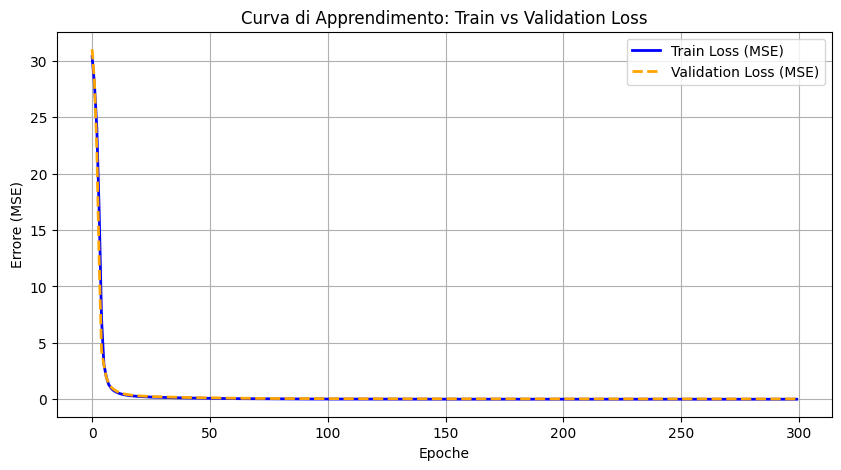

Test Loss (MSE) finale: 0.0366


In [61]:
import matplotlib.pyplot as plt

n_epoch = 300
train_losses = []
val_losses = []

for epoch in range(n_epoch):
    #training
    modello.train()
    perdita_totale_train = 0.0

    for inputs, targets in train_loader:
        optimizer.zero_grad()
        pred = modello(inputs)
        loss = loss_fun(pred, targets)
        loss.backward()
        optimizer.step()

        perdita_totale_train += loss.item()

    train_loss_medio = perdita_totale_train / len(train_loader)
    train_losses.append(train_loss_medio)

    # validation
    modello.eval()
    perdita_totale_val = 0.0

    with torch.no_grad():
        for inputs_val, targets_val in val_loader:
            pred_val = modello(inputs_val)
            loss_val = loss_fun(pred_val, targets_val)
            perdita_totale_val += loss_val.item()

    val_loss_medio = perdita_totale_val / len(val_loader)
    val_losses.append(val_loss_medio)

    if (epoch + 1) % 25 == 0:
        print(f"Epoca [{epoch + 1}/{n_epoch}] - Train Loss: {train_loss_medio:.4f} | Val Loss: {val_loss_medio:.4f}")

# curve di loss grafico
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss (MSE)', color='blue', linewidth=2)
plt.plot(val_losses, label='Validation Loss (MSE)', color='orange', linestyle='--', linewidth=2)
plt.xlabel('Epoche')
plt.ylabel('Errore (MSE)')
plt.title('Curva di Apprendimento: Train vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# test
modello.eval()
perdita_totale_test = 0.0

with torch.no_grad():
    for inputs_test, targets_test in test_loader:
        pred_test = modello(inputs_test)
        loss_test = loss_fun(pred_test, targets_test)
        perdita_totale_test += loss_test.item()

test_loss_medio = perdita_totale_test / len(test_loader)
print(f"Test Loss (MSE) finale: {test_loss_medio:.4f}")

Test visivo

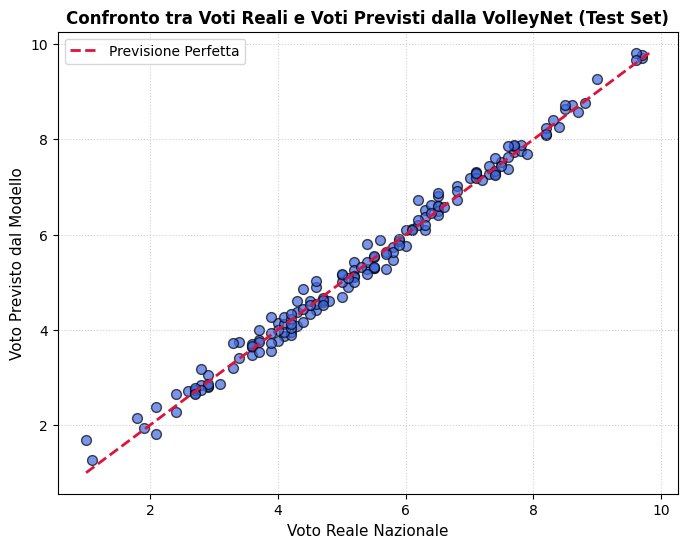

In [62]:
# dati e le previsioni del test set
tutti_i_reali = []
tutte_le_previsioni = []

modello.eval()
with torch.no_grad():
    for batch_dati in test_loader:
        inputs_test = batch_dati[0]
        targets_test = batch_dati[1]

        previsioni_test = modello(inputs_test)

        # Salviamo i valori convertendoli in liste Python (portandoli dalla GPU/tensore alla CPU)
        tutti_i_reali.extend(targets_test.squeeze().tolist())
        tutte_le_previsioni.extend(previsioni_test.squeeze().tolist())

plt.figure(figsize=(8, 6))
plt.scatter(tutti_i_reali, tutte_le_previsioni, color='royalblue', alpha=0.7, edgecolors='k', s=50)

valore_min = min(min(tutti_i_reali), min(tutte_le_previsioni))
valore_max = max(max(tutti_i_reali), max(tutte_le_previsioni))
plt.plot([valore_min, valore_max], [valore_min, valore_max], color='crimson', linestyle='--', linewidth=2, label='Previsione Perfetta')

plt.title('Confronto tra Voti Reali e Voti Previsti dalla VolleyNet (Test Set)', fontsize=12, fontweight='bold')
plt.xlabel('Voto Reale Nazionale', fontsize=11)
plt.ylabel('Voto Previsto dal Modello', fontsize=11)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

In [63]:
import torch
import pandas as pd

modello.eval()

# Scaliamo tutte le feature e facciamo fare le previsioni al modello potenziato
features_complete_scaled = scaler.transform(features)
with torch.no_grad():
    tensor_completo = torch.tensor(features_complete_scaled, dtype=torch.float32)
    previsioni = modello(tensor_completo)

# 3. Inseriamo il voto previsto nella tabella e arrotondiamolo a 1 decimale
tabella_volley_pro['Voto_Previsto'] = previsioni.squeeze().tolist()
tabella_volley_pro['Voto_Previsto'] = tabella_volley_pro['Voto_Previsto'].round(1)
tabella_volley_pro['Voto_Previsto'] = tabella_volley_pro['Voto_Previsto'].clip(lower=1.0, upper=10.0)

# 4. Associamo le frasi di giudizio anche al voto previsto usando le stesse soglie
soglie_voti = [0, 2.0, 4.0, 6.0, 7.5, 9.0, 10.0]
frasi_giudizio = [
    'Pessima per la nazionale',
    'Insufficiente',
    'Sufficiente / Da monitorare',
    'Buona / Ottima prospettiva',
    'Eccellente / Titolare',
    'Perfetta / Fuoriclasse'
]

tabella_volley_pro['Giudizio_Previsto'] = pd.cut(
    tabella_volley_pro['Voto_Previsto'],
    bins=soglie_voti,
    labels=frasi_giudizio,
    include_lowest=True
)

tabella_volley_pro['Voto_Previsto'] = tabella_volley_pro['Voto_Previsto'].clip(lower=1.0, upper=10.0)

# 5. Ordiniamo dal voto previsto più alto al più basso e prendiamo i top 10
top_10 = tabella_volley_pro.sort_values(by='Voto_Previsto', ascending=False).head(10)
print("TOP 10:\n")

for indice, riga in top_10.iterrows():
    print(f"Atleta: {riga['Atleta_ID']}  -->  Voto Reale: {riga['Voto_Nazionale']}  |  Voto AI: {riga['Voto_Previsto']}  |  Giudizio: {riga['Giudizio_Previsto']}")

TOP 10:

Atleta: ID942393  -->  Voto Reale: 10.0  |  Voto AI: 10.0  |  Giudizio: Perfetta / Fuoriclasse
Atleta: ID246389  -->  Voto Reale: 9.6  |  Voto AI: 9.8  |  Giudizio: Perfetta / Fuoriclasse
Atleta: ID855164  -->  Voto Reale: 9.7  |  Voto AI: 9.8  |  Giudizio: Perfetta / Fuoriclasse
Atleta: ID640659  -->  Voto Reale: 9.6  |  Voto AI: 9.7  |  Giudizio: Perfetta / Fuoriclasse
Atleta: ID653999  -->  Voto Reale: 9.7  |  Voto AI: 9.7  |  Giudizio: Perfetta / Fuoriclasse
Atleta: ID357802  -->  Voto Reale: 9.5  |  Voto AI: 9.5  |  Giudizio: Perfetta / Fuoriclasse
Atleta: ID307980  -->  Voto Reale: 9.4  |  Voto AI: 9.3  |  Giudizio: Perfetta / Fuoriclasse
Atleta: ID304615  -->  Voto Reale: 9.0  |  Voto AI: 9.3  |  Giudizio: Perfetta / Fuoriclasse
Atleta: ID451707  -->  Voto Reale: 9.0  |  Voto AI: 9.2  |  Giudizio: Perfetta / Fuoriclasse
Atleta: ID704055  -->  Voto Reale: 9.1  |  Voto AI: 9.1  |  Giudizio: Perfetta / Fuoriclasse


In [64]:
voto_massimo = tabella_volley_pro['Voto_Nazionale'].max()
voto_minimo = tabella_volley_pro['Voto_Nazionale'].min()

atleti_migliori = tabella_volley_pro[tabella_volley_pro['Voto_Nazionale'] == voto_massimo]
atleti_peggiori = tabella_volley_pro[tabella_volley_pro['Voto_Nazionale'] == voto_minimo]
colonne_da_mostrare = ['Atleta_ID', 'Eta', 'Voto_Nazionale', 'Voto_Previsto', 'Giudizio_Previsto']

print(f"Numero di atleti che hanno raggiunto il valore più massimo: {len(atleti_migliori)}")
display(atleti_migliori[colonne_da_mostrare])

print(f"Numero di atleti che hanno raggiunto il valore minimo: {len(atleti_peggiori)}")
display(atleti_peggiori[colonne_da_mostrare])

atleti_azzeccati = tabella_volley_pro[abs(tabella_volley_pro['Voto_Nazionale'] - tabella_volley_pro['Voto_Previsto']) < 0.01]
print(f"Numero di atleti azzeccati da AI con scarto inferiore a 0.01: {len(atleti_azzeccati)}")
display(atleti_azzeccati[colonne_da_mostrare])


Numero di atleti che hanno raggiunto il valore più massimo: 1


,Atleta_ID,Eta,Voto_Nazionale,Voto_Previsto,Giudizio_Previsto
504,ID942393,21,10.0,10.0,Perfetta / Fuoriclasse


Numero di atleti che hanno raggiunto il valore minimo: 1


,Atleta_ID,Eta,Voto_Nazionale,Voto_Previsto,Giudizio_Previsto
710,ID955778,30,1.0,1.7,Pessima per la nazionale


Numero di atleti azzeccati da AI con scarto inferiore a 0.01: 561


,Atleta_ID,Eta,Voto_Nazionale,Voto_Previsto,Giudizio_Previsto
0,ID760482,34,7.2,7.2,Buona / Ottima prospettiva
1,ID904462,20,6.2,6.2,Buona / Ottima prospettiva
2,ID969270,20,4.4,4.4,Sufficiente / Da monitorare
3,ID971149,23,5.1,5.1,Sufficiente / Da monitorare
4,ID548874,30,5.1,5.1,Sufficiente / Da monitorare
...,...,...,...,...,...
783,ID216953,21,6.6,6.6,Buona / Ottima prospettiva
784,ID576072,31,4.5,4.5,Sufficiente / Da monitorare
788,ID218533,21,2.7,2.7,Insufficiente
793,ID176898,33,5.5,5.5,Sufficiente / Da monitorare
